In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
df = pd.read_csv('/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv')

print(df.head())
print(df.columns.tolist())
print(df.shape)
print(df.dtypes)

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
(1000, 8)
gende

In [3]:
print(df.isnull().mean()*100)
print(df.isnull().sum())


gender                         0.0
race/ethnicity                 0.0
parental level of education    0.0
lunch                          0.0
test preparation course        0.0
math score                     0.0
reading score                  0.0
writing score                  0.0
dtype: float64
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


In [5]:
df['gender'] = df['gender'].str.lower()
df['lunch'] = df['lunch'].str.lower()
print(df[['gender','lunch']].head())

   gender         lunch
0  female      standard
1  female      standard
2  female      standard
3    male  free/reduced
4    male      standard


In [6]:
df['total_score'] = df['math_score']+df['reading_score']+df['writing_score']
top10=df.nlargest(10, 'total_score')
print(top10)

     gender race/ethnicity parental_level_of_education         lunch  \
458  female        group E           bachelor's degree      standard   
916    male        group E           bachelor's degree      standard   
962  female        group E          associate's degree      standard   
114  female        group E           bachelor's degree      standard   
179  female        group D            some high school      standard   
712  female        group D                some college      standard   
165  female        group C           bachelor's degree      standard   
625    male        group D                some college      standard   
149    male        group E          associate's degree  free/reduced   
685  female        group E             master's degree      standard   

    test_preparation_course  math_score  reading_score  writing_score  \
458                    none         100            100            100   
916               completed         100            100       

In [7]:
by_education=df.groupby('parental_level_of_education')['total_score'].mean().sort_values
by_race=df.groupby('race/ethnicity')['total_score'].mean().sort_values
by_lunch=df.groupby('lunch')['total_score'].mean()
by_gender =df.groupby('gender')['total_score'].mean()

print(by_education)
print("---")
print(by_race)
print("---")
print(by_lunch)
print("---")
print(by_gender)



<bound method Series.sort_values of parental_level_of_education
associate's degree    208.707207
bachelor's degree     215.771186
high school           189.290816
master's degree       220.796610
some college          205.429204
some high school      195.324022
Name: total_score, dtype: float64>
---
<bound method Series.sort_values of race/ethnicity
group A    188.977528
group B    196.405263
group C    201.394984
group D    207.538168
group E    218.257143
Name: total_score, dtype: float64>
---
lunch
free/reduced    186.597183
standard        212.511628
Name: total_score, dtype: float64
---
gender
female    208.708494
male      197.512448
Name: total_score, dtype: float64


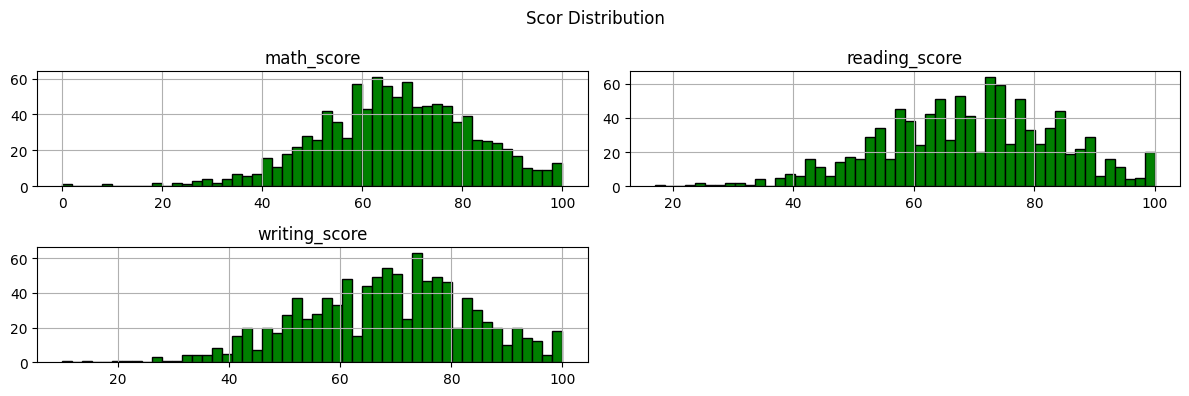

In [8]:
df[['math_score','reading_score','writing_score']].hist(bins=50,figsize=(12, 4),color='green',edgecolor='black')
plt.suptitle('Scor Distribution')
plt.tight_layout()
plt.show()

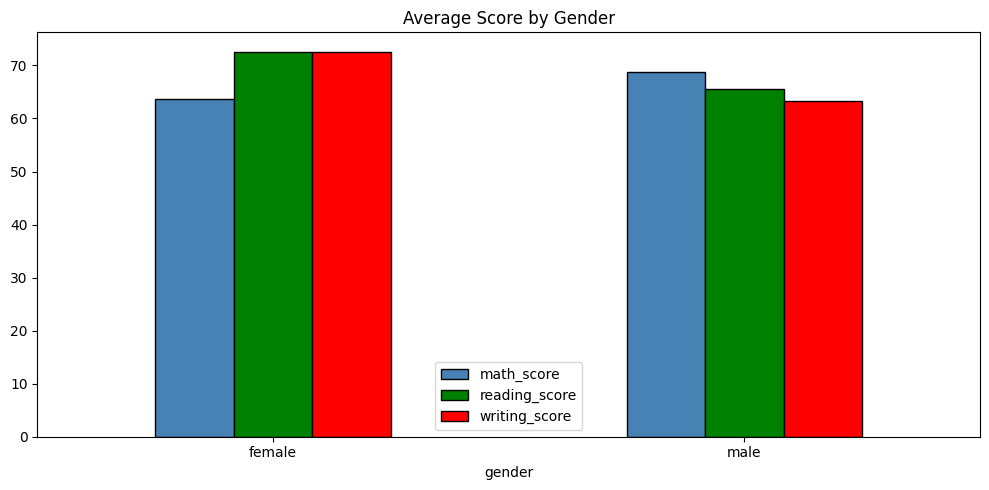

In [9]:
df.groupby('gender')[['math_score','reading_score','writing_score']].mean().plot(kind='bar', figsize=(10, 5), color=['steelblue', 'green', 'red'], edgecolor='black')
plt.title('Average Score by Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

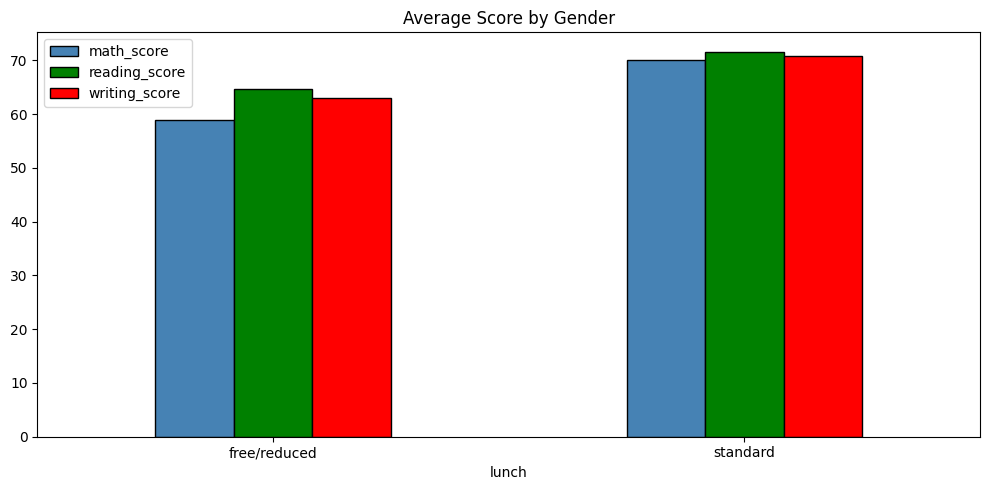

In [80]:
df.groupby('lunch')[['math_score', 'reading_score', 'writing_score']].mean().plot(kind='bar', figsize=(10, 5), color=['steelblue', 'green', 'red'], edgecolor='black')
plt.title('Average Score by Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

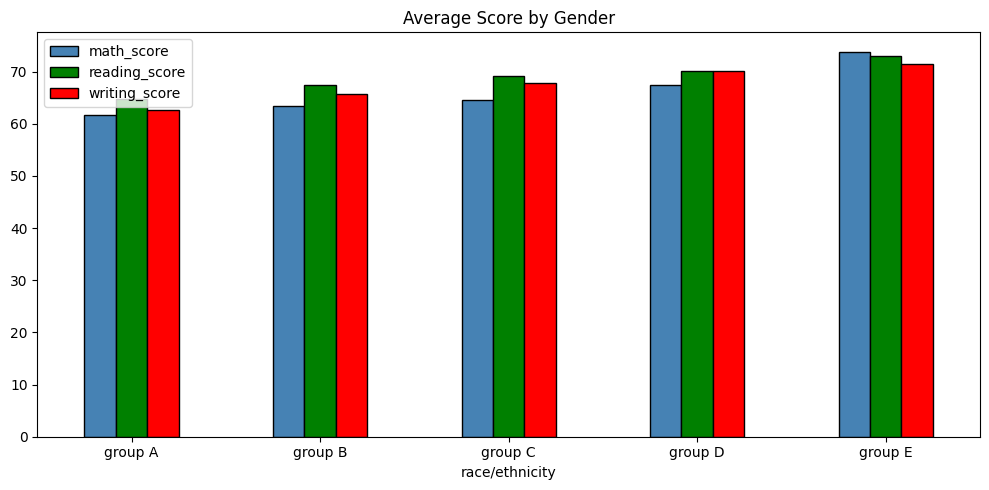

In [10]:
df.groupby('race/ethnicity')[['math_score', 'reading_score', 'writing_score']].mean().plot(kind='bar', figsize=(10, 5), color=['steelblue', 'green', 'red'], edgecolor='black')
plt.title('Average Score by Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

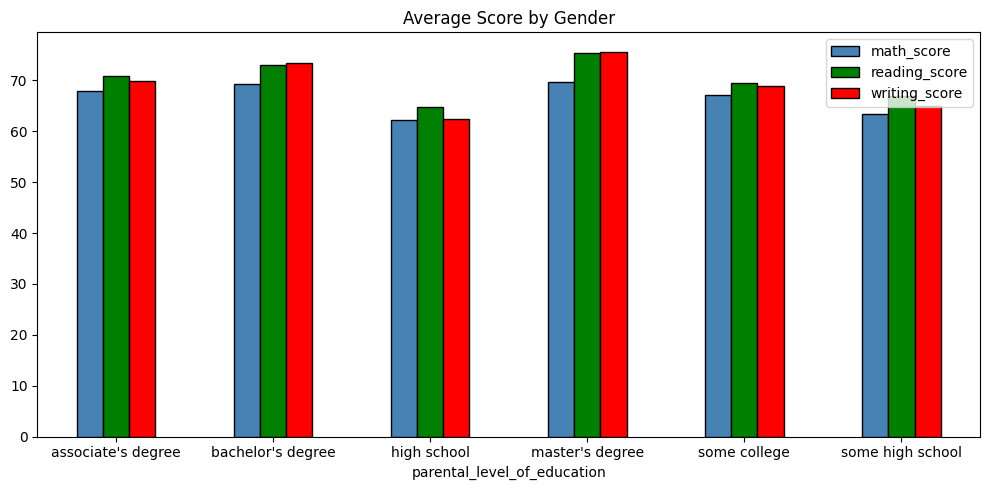

In [11]:
df.groupby('parental_level_of_education')[['math_score', 'reading_score', 'writing_score']].mean().plot(kind='bar', figsize=(10, 5), color=['steelblue', 'green', 'red'], edgecolor='black')
plt.title('Average Score by Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

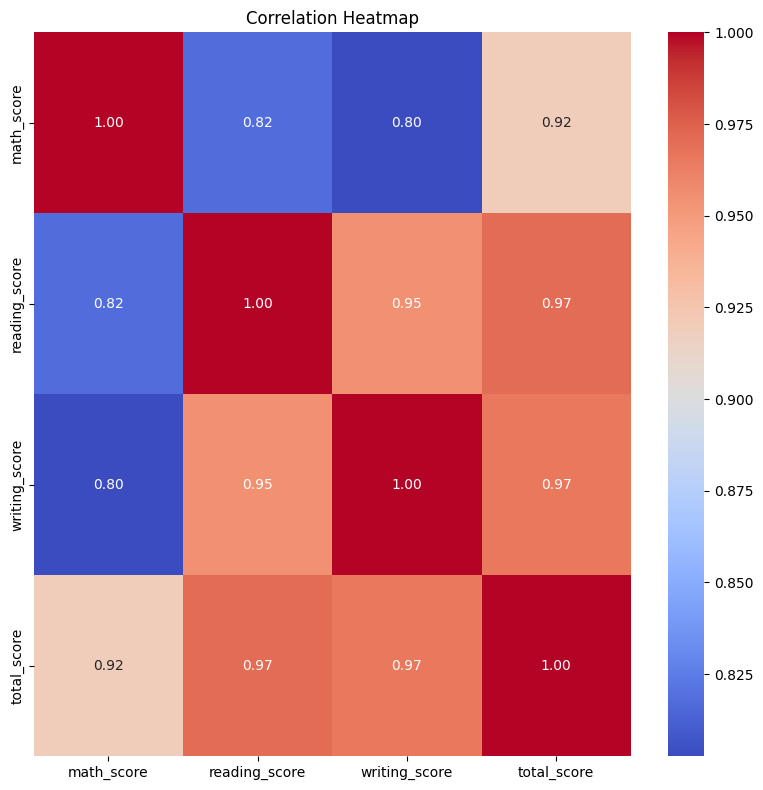

In [12]:
import seaborn as sns

corr = df[['math_score','reading_score','writing_score','total_score']].corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [49]:
df['gender'] = df['gender'].map({'female': 1,'male': 0})
df['lunch'] = df['lunch'].map({'standard': 1,'free/reduced': 0})
df['test_preparation_course'] = df['test_preparation_course'].map({'completed':1,'none':0})

In [ ]:
df = pd.get_dummies(df, columns=['race/ethnicity', 'parental_level_of_education'])
print(df.columns)

In [65]:
scaler = StandardScaler()
df[['math_score', 'reading_score', 'writing_score']] = scaler.fit_transform(df[['math_score', 'reading_score', 'writing_score']])